# Day 39/60 — Designing a KPI Monitoring System for Executives

## Business KPI Analytics

Building an executive KPI monitoring system to track customer, revenue,
profit, and retention performance using historical business data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Day 39 libraries imported successfully!")

Day 39 libraries imported successfully!


In [2]:
df = pd.read_csv("../cleaned_dataset.csv")

print("Business dataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Business dataset loaded successfully!
Dataset shape: (51290, 23)

Columns:
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'shipping_days', 'profit_margin']


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,shipping_days,profit_margin
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011,5,26.014706
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011,7,30.030000
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011,4,44.909091
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011,4,-57.900000
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011,7,33.131579


In [3]:
df["order_date"] = pd.to_datetime(df["order_date"])

print("Order date converted successfully!")

print("\nDate range:")
print(df["order_date"].min(), "to", df["order_date"].max())

display(df[["order_date", "sales", "profit"]].head())

Order date converted successfully!

Date range:
2011-01-01 00:00:00 to 2014-12-31 00:00:00


,order_date,sales,profit
0,2011-01-01,408.0,106.140
1,2011-01-01,120.0,36.036
2,2011-01-01,66.0,29.640
3,2011-01-01,45.0,-26.055
4,2011-01-01,114.0,37.770


In [4]:
total_revenue = df["sales"].sum()
total_profit = df["profit"].sum()
total_customers = df["customer_name"].nunique()
total_orders = df["order_id"].nunique()

average_order_value = total_revenue / total_orders

repeat_customer_count = (
    df.groupby("customer_name")["order_id"]
    .nunique()
    .gt(1)
    .sum()
)

repeat_customer_rate = (
    repeat_customer_count / total_customers
) * 100

average_orders_per_customer = (
    total_orders / total_customers
)

print("Executive KPI calculation completed successfully!")

print("\n--- BUSINESS KPI SUMMARY ---")
print("Total Revenue:", round(total_revenue, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Customers:", total_customers)
print("Total Orders:", total_orders)
print("Average Order Value:", round(average_order_value, 2))
print("Repeat Customer Rate:", round(repeat_customer_rate, 2), "%")
print("Average Orders per Customer:", round(average_orders_per_customer, 2))

Executive KPI calculation completed successfully!

--- BUSINESS KPI SUMMARY ---
Total Revenue: 12642905.0
Total Profit: 1469034.82
Total Customers: 795
Total Orders: 25035
Average Order Value: 505.01
Repeat Customer Rate: 100.0 %
Average Orders per Customer: 31.49


In [5]:
kpi_data = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Profit",
        "Total Customers",
        "Total Orders",
        "Average Order Value",
        "Repeat Customer Rate",
        "Average Orders per Customer"
    ],
    "Value": [
        total_revenue,
        total_profit,
        total_customers,
        total_orders,
        average_order_value,
        repeat_customer_rate,
        average_orders_per_customer
    ]
})

print("KPI table created successfully!")

display(kpi_data)

KPI table created successfully!


,KPI,Value
0,Total Revenue,1.264290e+07
1,Total Profit,1.469035e+06
2,Total Customers,7.950000e+02
3,Total Orders,2.503500e+04
4,Average Order Value,5.050092e+02
5,Repeat Customer Rate,1.000000e+02
6,Average Orders per Customer,3.149057e+01


In [6]:
df["year_month"] = df["order_date"].dt.to_period("M")

monthly_performance = (
    df.groupby("year_month")
    .agg(
        revenue=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_name", "nunique")
    )
    .reset_index()
)

monthly_performance["year_month"] = (
    monthly_performance["year_month"]
    .astype(str)
)

print("Monthly KPI trends calculated successfully!")

display(monthly_performance.head(10))

Monthly KPI trends calculated successfully!


,year_month,revenue,profit,orders,customers
0,2011-01,98902.0,8321.80096,216,195
1,2011-02,91152.0,12417.90698,183,163
2,2011-03,145726.0,15303.56826,277,235
3,2011-04,116927.0,12902.32438,267,228
4,2011-05,146762.0,12183.82870,295,240
5,2011-06,215214.0,23415.24702,468,341
6,2011-07,115518.0,5585.00352,250,219
7,2011-08,207570.0,23713.66772,443,325
8,2011-09,290230.0,35776.88394,527,381
9,2011-10,199070.0,25963.41834,401,314


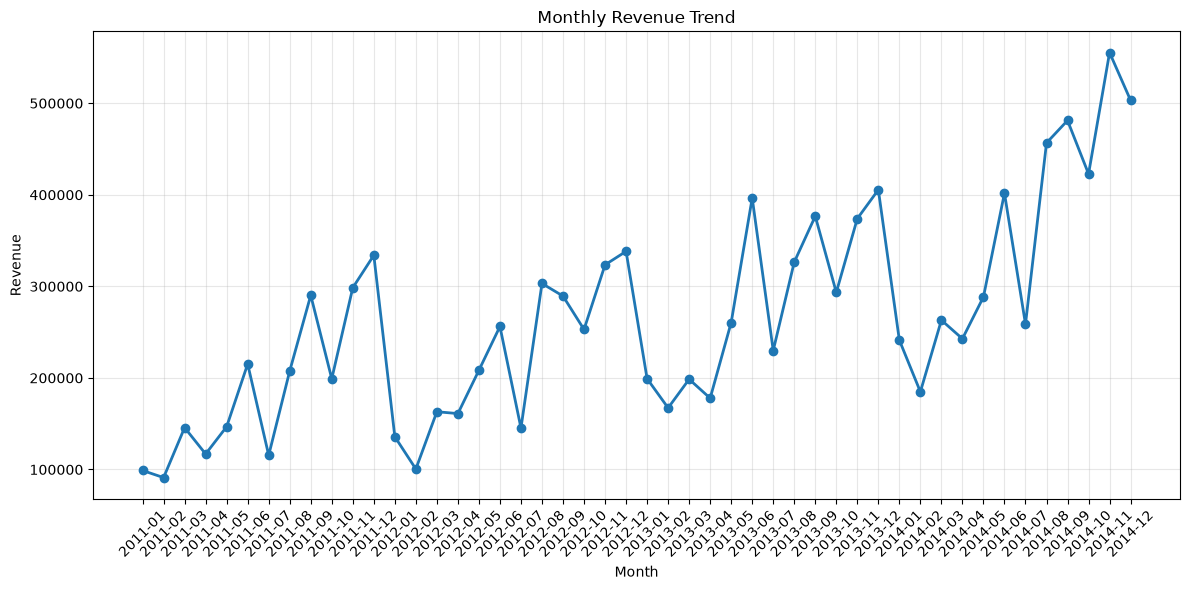

Monthly revenue trend created successfully!


In [7]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_performance["year_month"],
    monthly_performance["revenue"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Monthly revenue trend created successfully!")

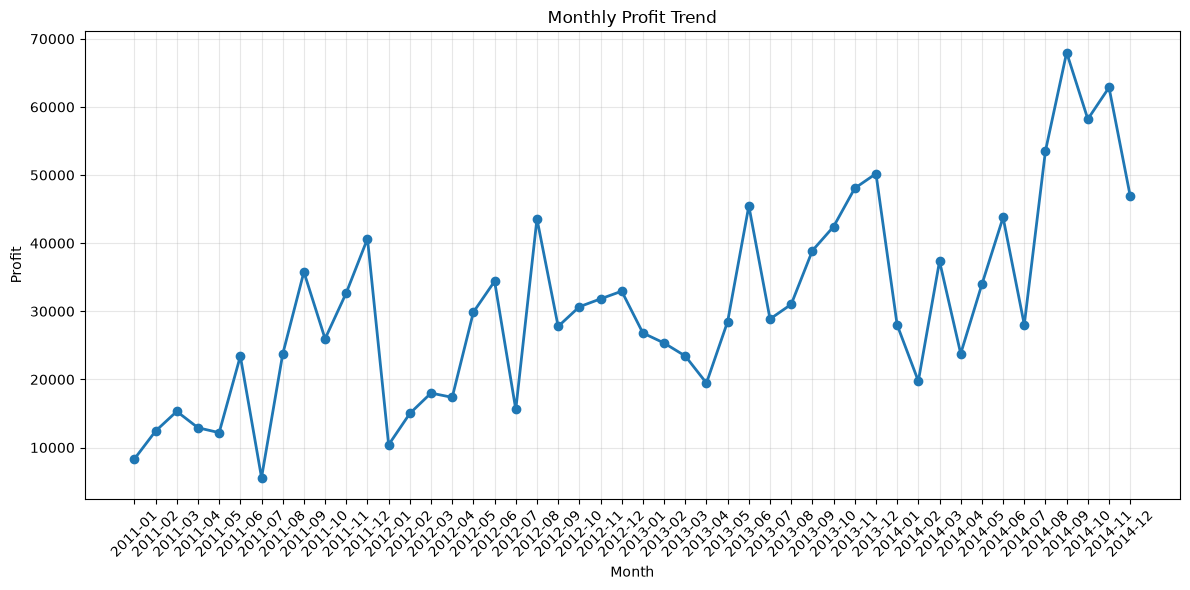

Monthly profit trend created successfully!


In [8]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_performance["year_month"],
    monthly_performance["profit"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Monthly profit trend created successfully!")

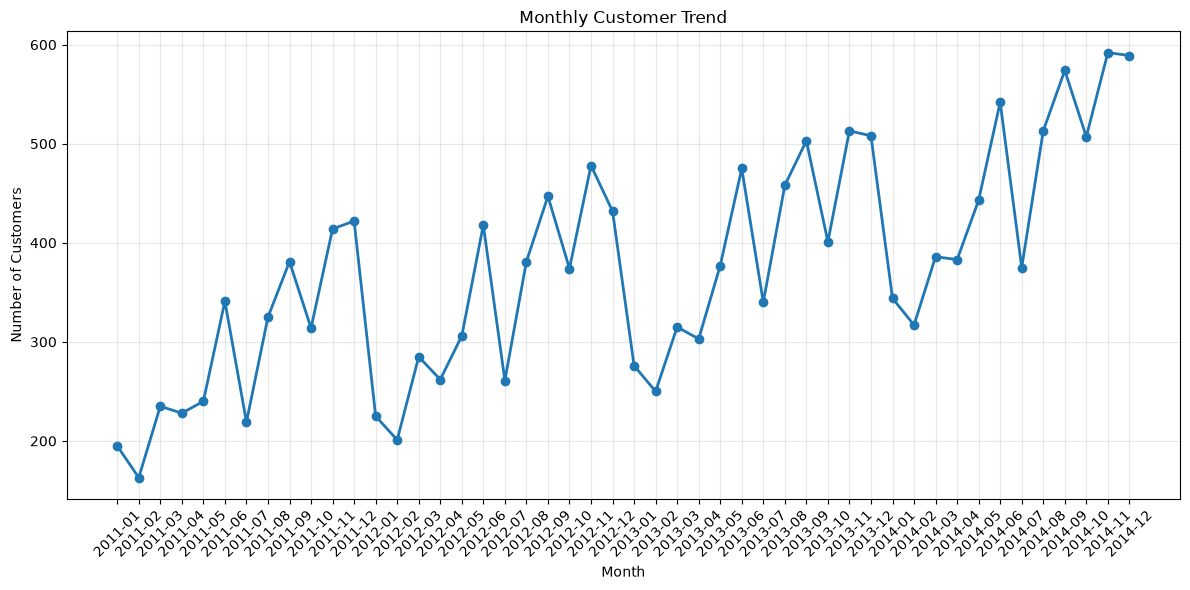

Monthly customer trend created successfully!


In [9]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_performance["year_month"],
    monthly_performance["customers"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Customer Trend")
plt.xlabel("Month")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Monthly customer trend created successfully!")

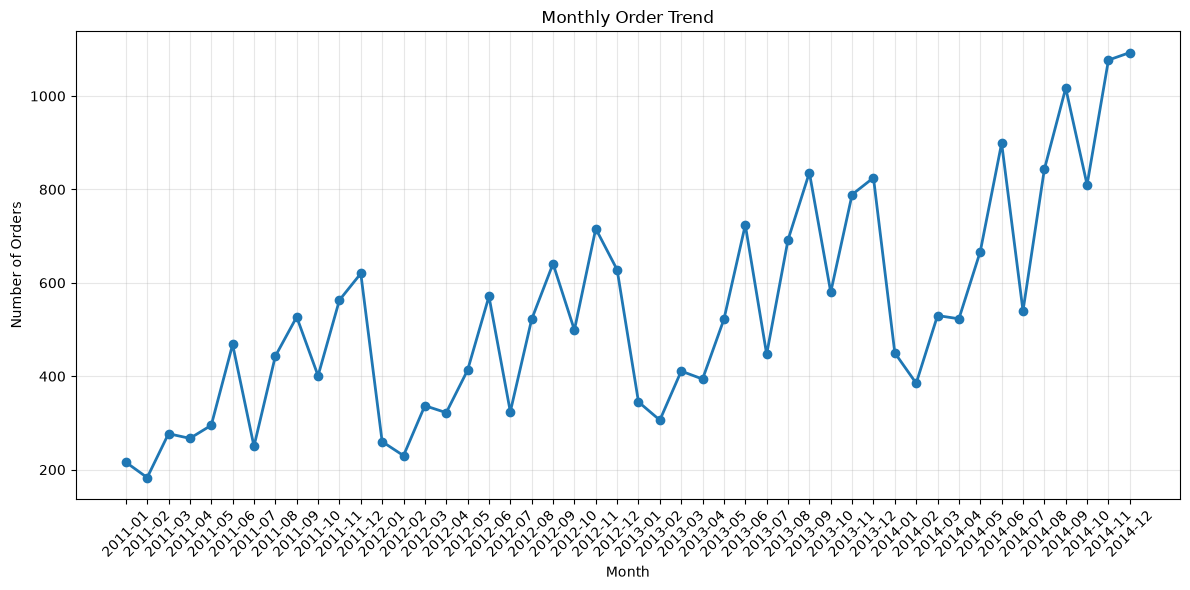

Monthly order trend created successfully!


In [10]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_performance["year_month"],
    monthly_performance["orders"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Monthly order trend created successfully!")

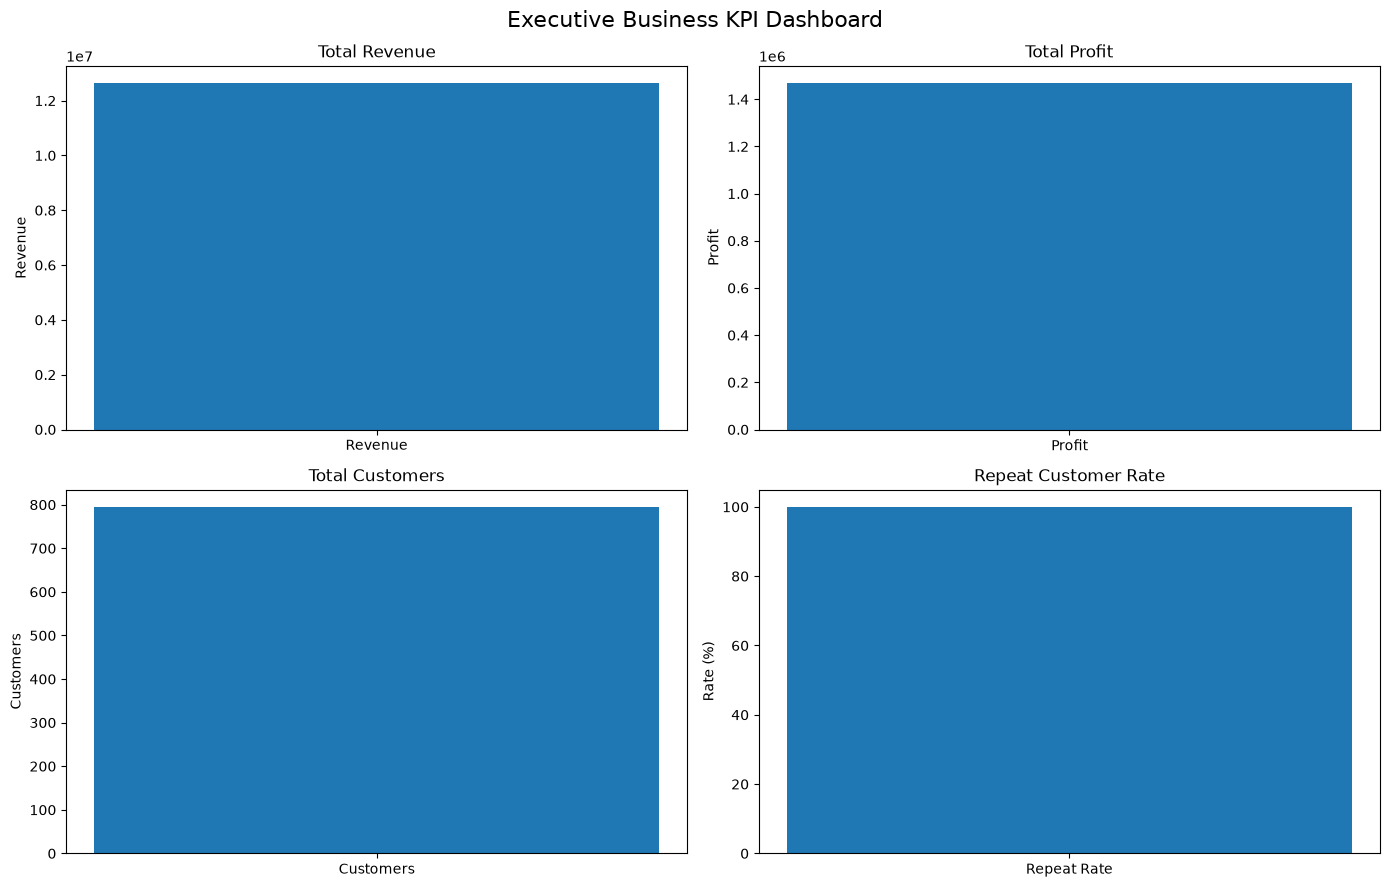

Executive KPI dashboard created successfully!


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].bar(
    ["Revenue"],
    [total_revenue]
)
axes[0, 0].set_title("Total Revenue")
axes[0, 0].set_ylabel("Revenue")

axes[0, 1].bar(
    ["Profit"],
    [total_profit]
)
axes[0, 1].set_title("Total Profit")
axes[0, 1].set_ylabel("Profit")

axes[1, 0].bar(
    ["Customers"],
    [total_customers]
)
axes[1, 0].set_title("Total Customers")
axes[1, 0].set_ylabel("Customers")

axes[1, 1].bar(
    ["Repeat Rate"],
    [repeat_customer_rate]
)
axes[1, 1].set_title("Repeat Customer Rate")
axes[1, 1].set_ylabel("Rate (%)")

plt.suptitle(
    "Executive Business KPI Dashboard",
    fontsize=16
)

plt.tight_layout()
plt.show()

print("Executive KPI dashboard created successfully!")

In [12]:
yearly_customer_orders = (
    df.groupby(["year", "customer_name"])["order_id"]
    .nunique()
    .reset_index()
)

yearly_customer_orders["customer_type"] = np.where(
    yearly_customer_orders["order_id"] > 1,
    "Repeat Customer",
    "One-Time Customer"
)

yearly_retention = (
    yearly_customer_orders
    .groupby(["year", "customer_type"])["customer_name"]
    .nunique()
    .unstack(fill_value=0)
)

yearly_retention["retention_rate"] = (
    yearly_retention.get("Repeat Customer", 0)
    /
    yearly_retention.sum(axis=1)
) * 100

print("Yearly customer retention calculated successfully!")

display(yearly_retention)

Yearly customer retention calculated successfully!


customer_type,One-Time Customer,Repeat Customer,retention_rate
year,,,
2011,12,783,98.490566
2012,5,790,99.371069
2013,0,795,100.000000
2014,0,794,100.000000


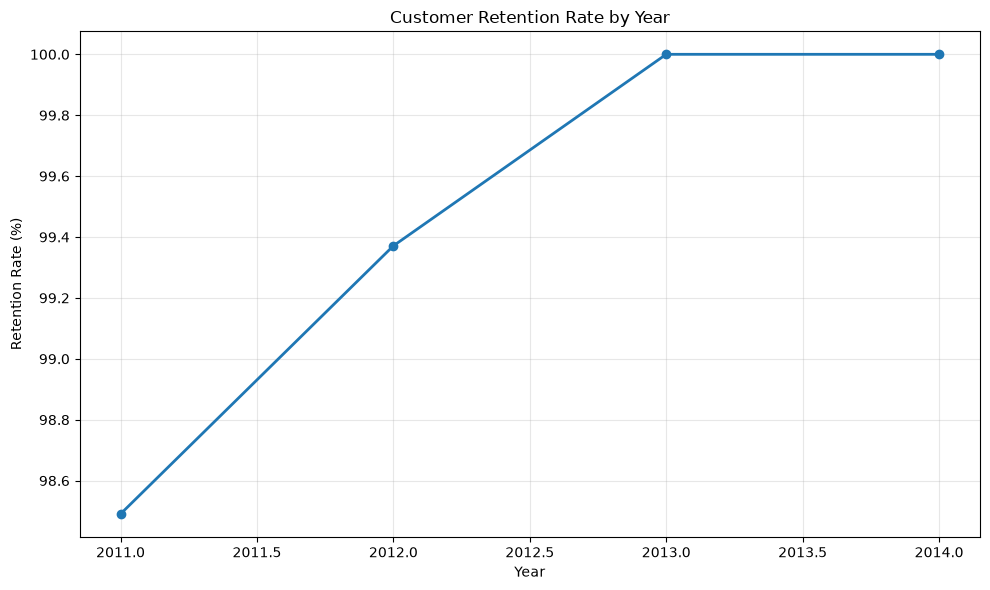

Customer retention trend created successfully!


In [13]:
plt.figure(figsize=(10, 6))

plt.plot(
    yearly_retention.index,
    yearly_retention["retention_rate"],
    marker="o",
    linewidth=2
)

plt.title("Customer Retention Rate by Year")
plt.xlabel("Year")
plt.ylabel("Retention Rate (%)")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

print("Customer retention trend created successfully!")

In [14]:
customer_metrics = df.groupby("customer_name").agg(
    total_revenue=("sales", "sum"),
    total_profit=("profit", "sum"),
    number_of_orders=("order_id", "nunique")
).reset_index()

customer_metrics["customer_clv"] = (
    customer_metrics["total_revenue"]
    / customer_metrics["number_of_orders"]
) * customer_metrics["number_of_orders"]

average_clv = customer_metrics["customer_clv"].mean()

high_value_customers = (
    customer_metrics["total_revenue"]
    >= customer_metrics["total_revenue"].median()
).sum()

print("Customer Lifetime Value KPI calculated successfully!")

print("\nAverage Customer Lifetime Value:")
print(round(average_clv, 2))

print("\nHigh-Value Customers:")
print(high_value_customers)

Customer Lifetime Value KPI calculated successfully!

Average Customer Lifetime Value:
15903.03

High-Value Customers:
398


In [15]:
kpi_data = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Profit",
        "Total Customers",
        "Total Orders",
        "Average Order Value",
        "Repeat Customer Rate",
        "Average Orders per Customer",
        "Average Customer Lifetime Value",
        "High-Value Customers"
    ],
    "Value": [
        total_revenue,
        total_profit,
        total_customers,
        total_orders,
        average_order_value,
        repeat_customer_rate,
        average_orders_per_customer,
        average_clv,
        high_value_customers
    ]
})

print("Executive KPI table updated successfully!")

display(kpi_data)

Executive KPI table updated successfully!


,KPI,Value
0,Total Revenue,1.264290e+07
1,Total Profit,1.469035e+06
2,Total Customers,7.950000e+02
3,Total Orders,2.503500e+04
4,Average Order Value,5.050092e+02
5,Repeat Customer Rate,1.000000e+02
6,Average Orders per Customer,3.149057e+01
7,Average Customer Lifetime Value,1.590303e+04
8,High-Value Customers,3.980000e+02


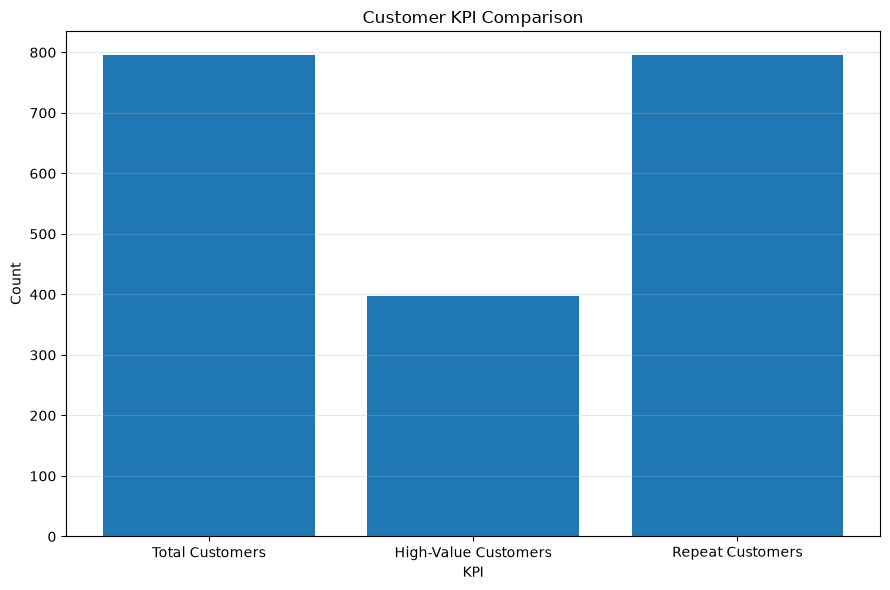

Customer KPI comparison chart created successfully!


In [16]:
customer_kpis = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "High-Value Customers",
        "Repeat Customers"
    ],
    "Value": [
        total_customers,
        high_value_customers,
        repeat_customer_count
    ]
})

plt.figure(figsize=(9, 6))

plt.bar(
    customer_kpis["KPI"],
    customer_kpis["Value"]
)

plt.title("Customer KPI Comparison")
plt.xlabel("KPI")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

print("Customer KPI comparison chart created successfully!")

In [17]:
kpi_status = pd.DataFrame({
    "KPI": [
        "Repeat Customer Rate",
        "Average Order Value",
        "Average Orders per Customer"
    ],
    "Actual": [
        repeat_customer_rate,
        average_order_value,
        average_orders_per_customer
    ],
    "Target": [
        30,
        200,
        2
    ]
})

kpi_status["Performance"] = np.where(
    kpi_status["Actual"] >= kpi_status["Target"],
    "Meeting Target",
    "Below Target"
)

print("KPI performance status calculated successfully!")

display(kpi_status)

KPI performance status calculated successfully!


,KPI,Actual,Target,Performance
0,Repeat Customer Rate,100.000000,30,Meeting Target
1,Average Order Value,505.009187,200,Meeting Target
2,Average Orders per Customer,31.490566,2,Meeting Target


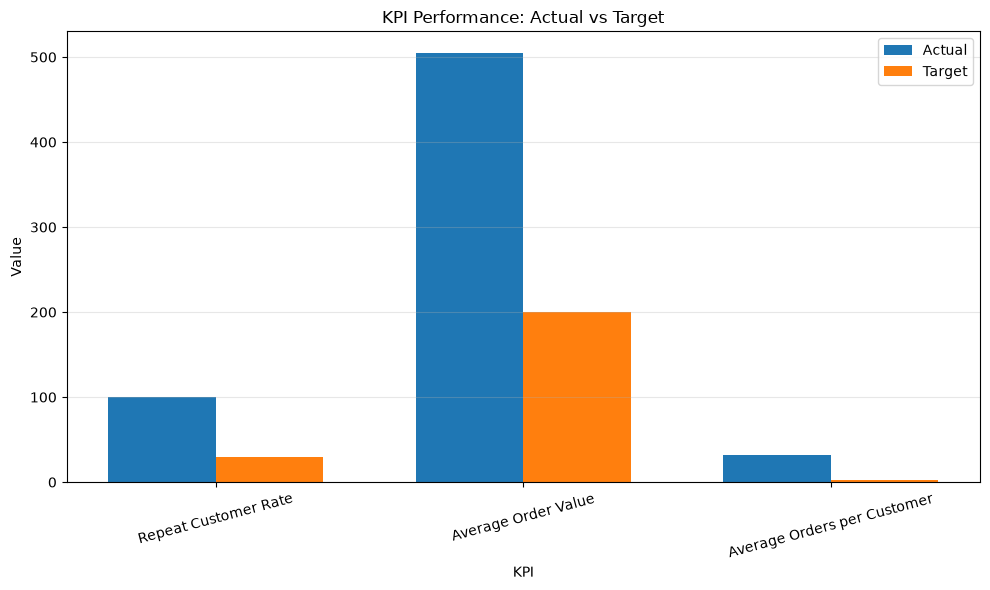

KPI performance visualization created successfully!


In [18]:
x = np.arange(len(kpi_status["KPI"]))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    kpi_status["Actual"],
    width,
    label="Actual"
)

plt.bar(
    x + width / 2,
    kpi_status["Target"],
    width,
    label="Target"
)

plt.title("KPI Performance: Actual vs Target")
plt.xlabel("KPI")
plt.ylabel("Value")

plt.xticks(
    x,
    kpi_status["KPI"],
    rotation=15
)

plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

print("KPI performance visualization created successfully!")

In [19]:
executive_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Profit",
        "Total Customers",
        "Total Orders",
        "Average Order Value",
        "Repeat Customer Rate",
        "Average Orders per Customer",
        "Average Customer Lifetime Value",
        "High-Value Customers"
    ],
    "Value": [
        round(total_revenue, 2),
        round(total_profit, 2),
        total_customers,
        total_orders,
        round(average_order_value, 2),
        round(repeat_customer_rate, 2),
        round(average_orders_per_customer, 2),
        round(average_clv, 2),
        high_value_customers
    ]
})

print("Executive KPI summary created successfully!")

display(executive_summary)

Executive KPI summary created successfully!


,Metric,Value
0,Total Revenue,12642905.00
1,Total Profit,1469034.82
2,Total Customers,795.00
3,Total Orders,25035.00
4,Average Order Value,505.01
5,Repeat Customer Rate,100.00
6,Average Orders per Customer,31.49
7,Average Customer Lifetime Value,15903.03
8,High-Value Customers,398.00


In [20]:
kpi_data.to_csv(
    "executive_kpi_summary.csv",
    index=False
)

monthly_performance.to_csv(
    "monthly_kpi_performance.csv",
    index=False
)

kpi_status.to_csv(
    "kpi_performance_status.csv",
    index=False
)

customer_kpis.to_csv(
    "customer_kpi_summary.csv",
    index=False
)

print("Day 39 KPI files saved successfully!")

print("\nCreated files:")
print("✓ executive_kpi_summary.csv")
print("✓ monthly_kpi_performance.csv")
print("✓ kpi_performance_status.csv")
print("✓ customer_kpi_summary.csv")

Day 39 KPI files saved successfully!

Created files:
✓ executive_kpi_summary.csv
✓ monthly_kpi_performance.csv
✓ kpi_performance_status.csv
✓ customer_kpi_summary.csv


In [21]:
report = f"""
# Day 39 — Business KPI Monitoring Report

## Executive KPI Overview

### Key Performance Indicators

- Total Revenue: {total_revenue:.2f}
- Total Profit: {total_profit:.2f}
- Total Customers: {total_customers}
- Total Orders: {total_orders}
- Average Order Value: {average_order_value:.2f}
- Repeat Customer Rate: {repeat_customer_rate:.2f}%
- Average Orders per Customer: {average_orders_per_customer:.2f}
- Average Customer Lifetime Value: {average_clv:.2f}
- High-Value Customers: {high_value_customers}

## Performance Monitoring

Monthly revenue, profit, customer, and order trends were analyzed
to monitor business performance over time.

## Customer Intelligence

Customer KPIs were used to monitor repeat-purchase behavior,
high-value customers, and customer lifetime value.

## Executive Insights

1. Revenue and profit trends help monitor overall business performance.
2. Customer and order trends help identify changes in business activity.
3. Repeat customer rate provides a simple view of customer retention.
4. Customer Lifetime Value helps understand historical customer value.
5. High-value customer counts help identify important customer groups.
6. KPI targets can help executives quickly identify areas requiring attention.

## Business Value

A KPI monitoring system provides executives with a consolidated view
of revenue, profit, customers, orders, and retention-related metrics.
This supports faster business monitoring and data-driven decision making.

## Limitations

The repeat customer rate is a simple repeat-purchase metric and is not
a formal cohort retention calculation.

Customer Lifetime Value in this project is based on historical revenue
and should not be interpreted as a predictive CLV model.

The KPI targets used for performance comparison are example benchmarks
created for this project and are not industry-standard targets.

## Future Improvements

- Real-time KPI monitoring
- Interactive dashboard application
- Cohort retention analysis
- Predictive Customer Lifetime Value
- Automated KPI alerts
- Profit-margin monitoring
"""

with open("business_kpi_report.md", "w", encoding="utf-8") as file:
    file.write(report)

print("Business KPI report created successfully!")
print("✓ business_kpi_report.md")

Business KPI report created successfully!
✓ business_kpi_report.md


In [22]:
import os

day39_files = os.listdir(".")

print("Day 39 files:")

for file in day39_files:
    print("✓", file)

Day 39 files:
✓ business_kpi_report.md
✓ customer_kpi_summary.csv
✓ day39.ipynb
✓ executive_kpi_summary.csv
✓ kpi_performance_status.csv
✓ monthly_kpi_performance.csv
✓ README.md
